In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

In [114]:
df = pd.read_csv(r"C:\Users\admin\PORKODI CLG\Data-Science-Learning\Task 35\loan_dataset.csv")
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [115]:
df["Loan_Status"] = np.where(df["Credit_History"] == 1, "Y", "N")

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
 12  Loan_Status        367 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 37.4+ KB


In [117]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
Loan_Status           0
dtype: int64

In [118]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [119]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [120]:
df = df.drop("Loan_ID", axis=1)
df = pd.get_dummies(df, drop_first=True)
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5720,0,110.0,360.0,1.0,True,True,False,False,False,False,False,False,True,True
1,3076,1500,126.0,360.0,1.0,True,True,True,False,False,False,False,False,True,True
2,5000,1800,208.0,360.0,1.0,True,True,False,True,False,False,False,False,True,True
3,2340,2546,100.0,360.0,1.0,True,True,False,True,False,False,False,False,True,False
4,3276,0,78.0,360.0,1.0,True,False,False,False,False,True,False,False,True,True


In [121]:
print(df.shape)

(367, 15)


In [122]:
X = df.drop("Loan_Status_Y", axis=1)
y = df["Loan_Status_Y"]

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [124]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [125]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9324324324324325


In [126]:
result = permutation_importance(model,X_test,y_test,n_repeats=10,random_state=42)

In [134]:
importance = pd.DataFrame({"Feature": X_test.columns,
                           "Importance": result.importances_mean})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)

                    Feature  Importance
4            Credit_History    0.332432
0           ApplicantIncome    0.000000
1         CoapplicantIncome    0.000000
2                LoanAmount    0.000000
3          Loan_Amount_Term    0.000000
5               Gender_Male    0.000000
6               Married_Yes    0.000000
7              Dependents_1    0.000000
8              Dependents_2    0.000000
9             Dependents_3+    0.000000
10   Education_Not Graduate    0.000000
11        Self_Employed_Yes    0.000000
13      Property_Area_Urban    0.000000
12  Property_Area_Semiurban   -0.006757


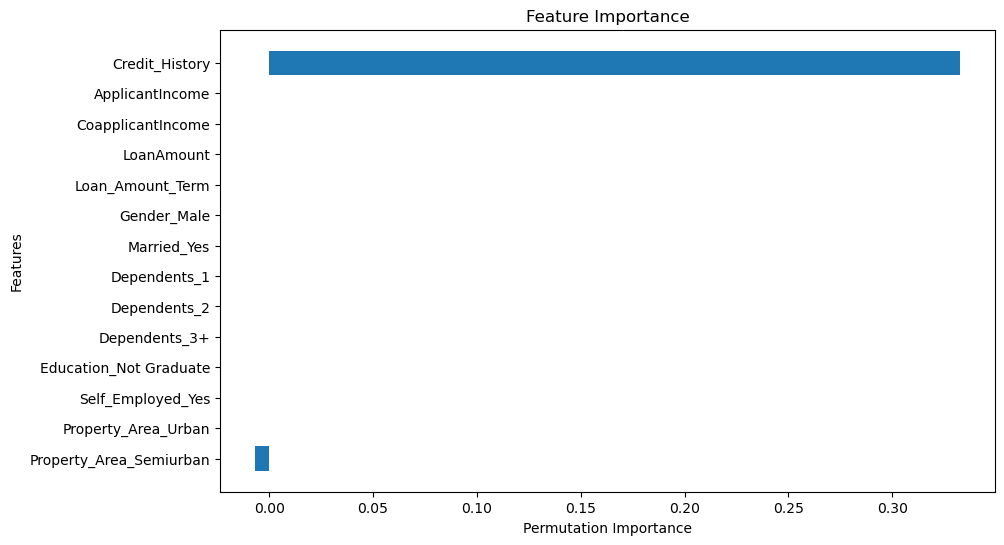

In [135]:
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

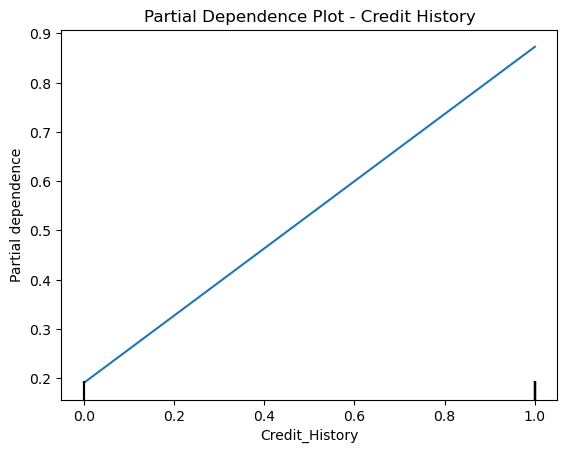

In [136]:
PartialDependenceDisplay.from_estimator(model,X_test,features=["Credit_History"])

plt.title("Partial Dependence Plot - Credit History")
plt.show()

In [137]:
explainer = shap.TreeExplainer(model)

In [138]:
shap_values = explainer.shap_values(X_test)

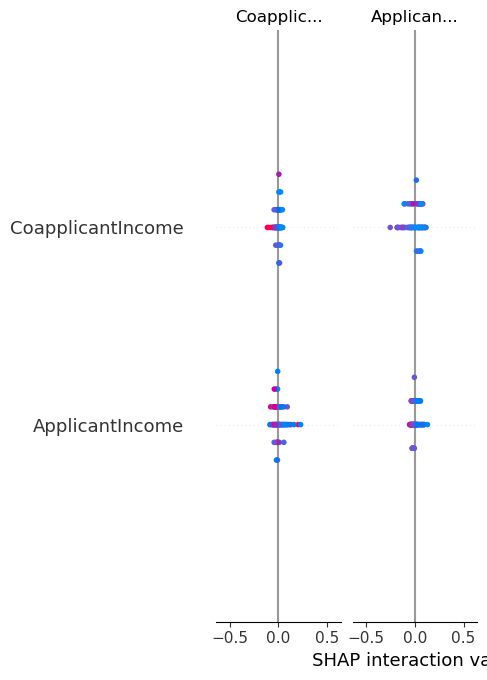

In [139]:
shap.summary_plot(shap_values, X_test)

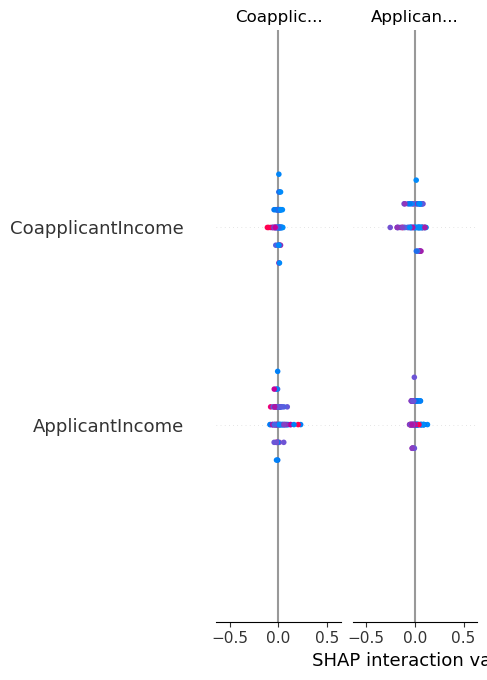

In [142]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# Model Interpretation Report

## Model
Random Forest Classifier

## Global Explanation
Permutation Importance identified the most influential features for predicting loan approval.

The Partial Dependence Plot shows how changes in Credit History affect the model's prediction.

SHAP Summary Plot explains the overall contribution of each feature across all predictions.

## Local Explanation
The SHAP explanation for one applicant shows how each feature contributed positively or negatively to the prediction.

## Limitations
- Feature importance does not imply causation.
- Correlated features can affect interpretation.
- SHAP calculations can be computationally expensive.
- Partial Dependence Plots assume feature independence.

## Conclusion
The model is interpretable using Permutation Importance, Partial Dependence Plots, and SHAP. These techniques provide both global and local explanations, helping stakeholders understand the model's behavior.